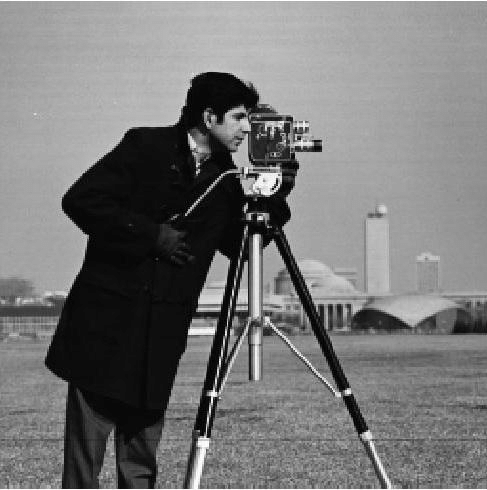

In [1]:
import sys
sys.path.append('../src')

from PIL import Image, ImageOps, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets
from ipywidgets import interactive, HBox, VBox, interact
from IPython.display import clear_output
from image.processing import preprocess_img, DITHER_MODES

IMG_PATH = "../imgs/cameraman.png"
orig_img = Image.open(IMG_PATH).convert("RGB")
display(orig_img)

In [2]:
def i_preprocess_img(
        scale_factor=0.5,
        contrast=1.0,
        brightness=1.0,
        sharpness=1.0,
        enhance_edges=0.0,
        quantize_colors=128,
        eq=0.0,
        dither=DITHER_MODES.NONE,
        grayscale=True):
    prep_img = preprocess_img(
        img=orig_img,
        scale_factor=scale_factor,
        contrast=contrast,
        brightness=brightness,
        eq=eq,
        quantize_colors=quantize_colors,
        dither=dither,
        sharpness=sharpness,
        enhance_edges=enhance_edges,
        grayscale=grayscale)
    
    plt.imshow(prep_img, cmap='gray', vmin=0, vmax=255, interpolation='none')
    plt.figure(figsize=(6, 3))
    plt.xticks([x for x in range(0, len(prep_img.histogram()), 50)])
    plt.bar([x for x in range(0, len(prep_img.histogram()))],
            prep_img.histogram())
    plt.grid()
    plt.show()
    return prep_img

interactive_preprocess = interactive(i_preprocess_img,
                                     scale_factor=(0.01, 1, 0.01),
                                     contrast=(0, 2, 0.01),
                                     brightness=(0, 2, 0.01),
                                     sharpness=(0, 2, 0.01),
                                     eq=(0, 1, 0.01),
                                     enhance_edges=(0, 1, 0.01),
                                     quantize_colors=(1, 256, 1),
                                     dither=DITHER_MODES,
                                     grayscale=True)

controls = VBox(interactive_preprocess.children[:-1])
display(HBox((controls, interactive_preprocess.children[-1])))

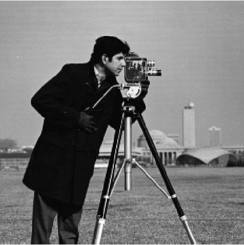

In [3]:
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.line_heuristics.utils import get_line_height
from palette.symbol2value import get_asciis, symbols_sorted
from rendering.ansi_colorizer import colorize_symbols, AnsiColorizer
from rendering.image import render_symbols_img
from rendering.terminal import print_gallery

FONT_PATH = "../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 16
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
SYMBOLS = symbols_sorted(get_asciis(), FONT)
MAX_WIDTH = 80
MAX_HEIGHT = 24

prep_img = interactive_preprocess.result
display(prep_img)



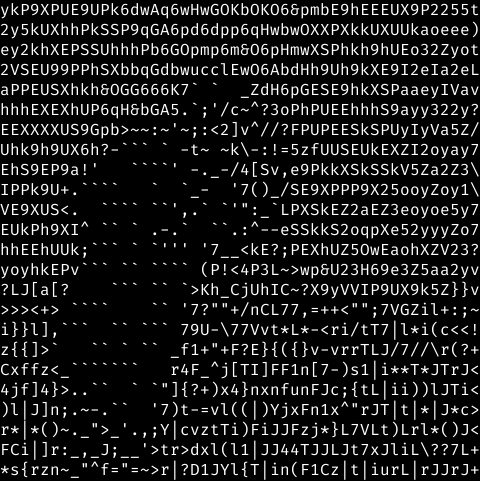

------------------------------------------------------
 | ykP9XPUE9UPk6dwAq6wHwGOKbOKO6&pmbE9hEEEUX9P2255t | 
 | 2y5kUXhhPkSSP9qGA6pd6dpp6qHwbwOXXPXkkUXUUkaoeee) | 
 | ey2khXEPSSUhhhPb6GOpmp6m&O6pHmwXSPhkh9hUEo32Zyot | 
 | 2VSEU99PPhSXbbqGdbwucclEwO6AbdHh9Uh9kXE9I2eIa2eL | 
 | aPPEUSXhkh&OGG666K7` `  _ZdH6pGESE9hkXSPaaeyIVav | 
 | hhhEXEXhUP6qH&bGA5.`;'/c~^?3oPhPUEEhhhS9ayy322y? | 
 | EEXXXXUS9Gpb>~~:~'~;:<2]v^//?FPUPEESkSPUyIyVa5Z/ | 
 | Uhk9h9UX6h?-``` ` -t~ ~k\-:!=5zfUUSEUkEXZI2oyay7 | 
 | EhS9EP9a!'   ````' -._-/4[Sv,e9PkkXSkSSkV5Za2Z3\ | 
 | IPPk9U+.````   `  `_-  '7()_/SE9XPPP9X25ooyZoy1\ | 
 | VE9XUS<.  ```` ``',.` `'":_`LPXSkEZ2aEZ3eoyoe5y7 | 
 | EUkPh9XI^ `` ` .-.`  ``.:^--eSSkkS2oqpXe52yyyZo7 | 
 | hhEEhUUk;``` ` `''' '7__<kE?;PEXhUZ5OwEaohXZV23? | 
 | yoyhkEPv``` `` ```` (P!<4P3L~>wp&U23H69e3Z5aa2yv | 
 | ?LJ[a[?    ``` `` `>Kh_CjUhIC~?X9yVVIP9UX9k5Z}}v | 
 | >>><+> ````    `` '7?""+/nCL77,=++<"";7VGZil+:;~ | 
 | i}}l],```  `` ``` 79U-\77Vvt*L*-<ri/tT7|l*i(c<<! | 
 | z{{]>` 

In [4]:
from converters.tile.bin_1d import Tile2Symb1dBin
converter = LineConverter(tile_converter=Tile2Symb1dBin(symbols=SYMBOLS,
                                                        font=FONT,
                                                        bins=16))

res_arr = ImgConverter(converter, FONT).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))

res_arr = colorize_symbols(orig_img, res_arr, FONT, AnsiColorizer(bg_brightness_scale=0.5, use_ansi_256_colors=False))
print_gallery([res_arr], 1)

In [5]:
from converters.tile.bin_2d import Tile2Symb2dBin
converter = LineConverter(tile_converter=Tile2Symb2dBin(symbols=SYMBOLS,
                                                        font=FONT))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

TypeError: ImgConverter.__init__() missing 1 required positional argument: 'font'

d:\CS Projects\python-playground\python-ascii-art\notebooks\../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


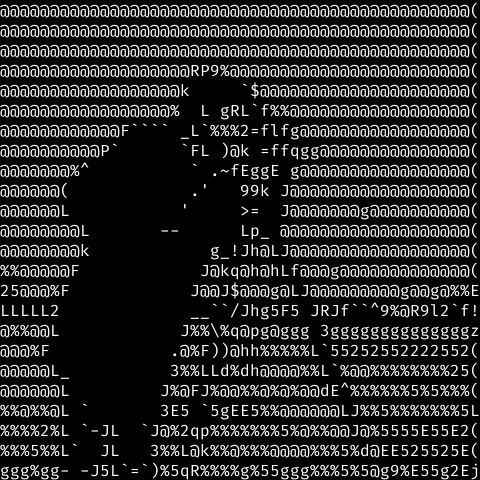

------------------------------------------------------
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@RP9%@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@k     `$@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@%  L gRL`f%%@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@F```` _L`%%%2=flfg@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@P`      `FL )@k =ffqgg@@@@@@@@@@@@@@@( | 
 | @@@@@@@%^          ` .~fEggE g@@@@@@@@@@@@@@@@@( | 
 | @@@@@@(            .'   99k J@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@L           '     >=  J@@@@@@@g@@@@@@@@@@( | 
 | @@@@@@@@L       --      Lp_ @@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@k            g_!Jh@LJ@@@@@@@@@@@@@@@@@@( | 
 | %%@@@@@F            J@kq@h@hLf@@@g@@@@@@@@@@@@@( | 
 | 25@@@%F            J@@J$@@@g@LJ@@@@@@@@@g@@g@%%E | 
 | LLLLL2             __``/Jhg5F5 JRJf``^9%@R9l2`f! | 
 | @%%@@L            J%%\%q@pg@ggg 3ggggggggggggggz | 
 | @@@%F  

In [ ]:
from converters.tile.nearest import Tile2SymbNearest
converter = LineConverter(tile_converter=Tile2SymbNearest(symbols=SYMBOLS,
                                                          font=FONT))

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, col_width=4, max_lines=MAX_HEIGHT, line_height=8)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

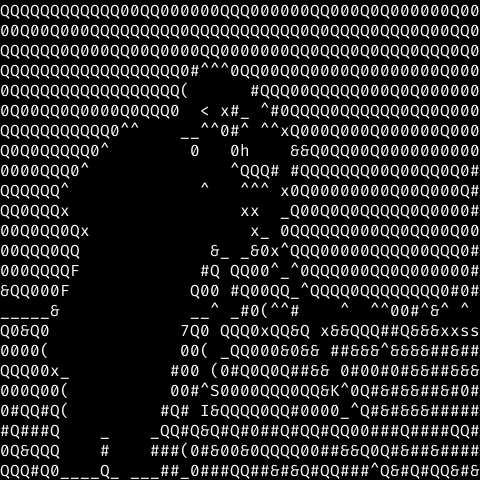

------------------------------------------------------
 | QQQQQQQQQQQQ00QQ000000QQQ000000QQ000Q0Q000000Q00 | 
 | 00Q00Q000QQQQQQQQQ0QQQQQQQQQQQ0Q0QQQQ0QQQ0Q00QQ0 | 
 | QQQQQQ0Q000QQ00Q0000QQ0000000QQ0QQQ0Q0QQQ0QQQ0Q0 | 
 | QQQQQQQQQQQQQQQQQQ0#^^^0QQ00Q0Q0000Q00000000Q000 | 
 | 0QQQQQQQQQQQQQQQQQ(      #QQQ00QQQQQ000Q0Q000000 | 
 | 0Q00QQ0Q0000Q0QQQ0  < x#_ ^#0QQQQ0QQQQQQ0QQ0Q000 | 
 | QQQQQQQQQQQ0^^    __^^0#^ ^^xQ000Q000Q000000Q000 | 
 | Q0Q0QQQQQ0^        0   0h    &&Q0QQ00Q0000000000 | 
 | 0000QQQ0^              ^QQQ# #QQQQQQQ00Q00QQ0Q0# | 
 | QQQQQQ^             ^   ^^^ x0Q00000000Q00Q000Q# | 
 | QQ0QQQx                 xx  _Q00Q0Q0QQQQQ0Q0000# | 
 | 00Q0QQ0Qx                x_ 0QQQQQQ000QQ0QQ00Q00 | 
 | 00QQQ0QQ             &_ _&0x^QQQ00000QQQQ00QQQ0# | 
 | 000QQQQF            #Q QQ00^_^0QQQ000QQ0Q000000# | 
 | &QQ000F            Q00 #Q00QQ_^QQQQ0QQQQQQQQ0#0# | 
 | _____&             __^ _#0(^^#    ^  ^^00#^&^ ^  | 
 | Q0&Q0             7Q0 QQQ0xQQ&Q x&&QQQ##Q&&&xxss | 
 | 0000(  

In [ ]:
from converters.line_heuristics.greedy import GreedyLineSearch
converter = GreedyLineSearch(symbols=SYMBOLS[::5],
                             font=FONT)

res_arr = ImgConverter(converter).img2symbols(prep_img,
                                              max_cols=MAX_WIDTH,
                                              max_lines=MAX_HEIGHT, 
                                              line_height=get_line_height(SYMBOLS, FONT))
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

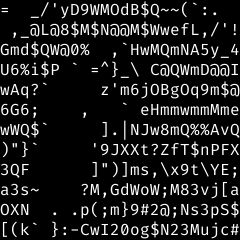

------------------------------
 | =  _/'yD9WMOdB$Q~~(`:.   | 
 |  ,_@L@8$M$N@@M$WwefL,/'! | 
 | Gmd$QW@0%  ,`HwMQmNA5y_4 | 
 | U6%i$P ` =^}_\ C@QWmD@@I | 
 | wAq?`     z'm6jOBgOq9m$@ | 
 | 6G6;    ,   ` eHmmwmmMme | 
 | wWQ$`     ].|NJw8mQ%%AvQ | 
 | )"}`     '9JXXt?ZfT$nPFX | 
 | 3QF      ]")]ms,\x9t\YE; | 
 | a3s~    ?M,GdWoW;M83vj[a | 
 | OXN  . .p(;m}9#2@;Ns3pS$ | 
 | [(k` }:-CwI20og$N23Mujc# | 
------------------------------


In [ ]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch
from converters.tile.bin_2d import Tile2Symb2dBin

tile_converter = Tile2Symb2dBin(symbols=SYMBOLS, font=FONT)
converter = HarmonyLineSearch(symbols=SYMBOLS,
                              font=FONT,
                              pop_count=15,
                              generations=40,
                              tile_converter=tile_converter)

img_converter_gen = ImgConverter(converter, FONT).img2symbols_lazy(prep_img,
                                              max_cols=MAX_WIDTH // 2,
                                              max_lines=MAX_HEIGHT // 2, 
                                              line_height=get_line_height(SYMBOLS, FONT),
                                              gens_per_step=20)

for res_arr in img_converter_gen:
    clear_output()
    display(render_symbols_img(res_arr, FONT))
    print_gallery([res_arr], 1)

In [6]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch
from converters.tile.bin_2d import Tile2Symb2dBin

tile_converter = Tile2Symb2dBin(symbols=SYMBOLS, font=FONT)
converter = HarmonyLineSearch(symbols=SYMBOLS,
                              font=FONT,
                              pop_count=15,
                              generations=10,
                              tile_converter=tile_converter)

res_arr = ImgConverter(converter, FONT).img2symbols(prep_img,
                                              max_cols=MAX_WIDTH,
                                              max_lines=MAX_HEIGHT, 
                                              line_height=get_line_height(SYMBOLS, FONT))

res_arr = colorize_symbols(orig_img, res_arr, FONT, AnsiColorizer(bg_brightness_scale=0.5, use_ansi_256_colors=False))
print_gallery([res_arr], 1)

------------------------------------------------------
 | +~^ _fFds0I<#QaI~WB^Q@N%Q00QQVI&|>ubbSSqy(];_;'" | 
 | '=G+ Um!%wbAQ33Q$gQbQQQgQG QQQQRTQ%va_UAeG y`>W, | 
 | ]h!=,:-=b'D4'0Q_Q@Qwa@QB$0QeC@QQNZOKxk^[` _Ac:J> | 
 | U6AAtmtQQQQQQQQQgQgP^^?OQQQQQQQQQQOUG@6GU6Um=m63 | 
 | mUUGm6wQQQQQQQQQQQ7     'hQQQQQQQQUmUUUUGGUU6mU4 | 
 | mGAA68QQQQQQQQQQQH` , ;t;!7#KQQQQwUGUmAUUmmmG6Gn | 
 | ZAU$Go%QQQQQl^^^' _;!75V{!F7;Am0bOA6wmUG6AGmGGU2 | 
 | 6m6AAOQQQD?'      'V! ~wc-:!=euy8GmAAmUAUmUAmGA2 | 
 | GGUA6GQ#^          ' .`*kaaL e666mGmGG6A6m6UGAm[ | 
 | GGAGmG?            .'  `???';6G6GAGAGUGGmA6UGAUc | 
 | Am6G6G;           '     !;  )AG6mAUGmOUAmmmmUAmt | 
 | GmwbGUD6_       -       :< `Gmm6U6UCQQAG6OU9G6mg | 
 | AAAm6mmA!            ;.-^w6;=6wwHpUAQQAmUAmAGmmI | 
 | 5kXGUmmF            aw!;nQ6r;?8OQwmmQQmGUU6Am6GC | 
 | cj]5H9?            ;Q8-4nQweZ:7bDb#GH8mwwwwmUES} | 
 | ;;;;;;             ;j!:c(VZ{7}.~)v7!~=?9&9f}/!=! | 
 | C4nCn'            )KR-);)Z;2uLj c1s;a;;L1ixJ;;;; | 
 | Iun[(  